In [1]:
!pip install nltk wordcloud -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [3]:
df = pd.read_csv("CEAS_08.csv")

print("Dataset Loaded Successfully!")

print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

df.head()

Dataset Loaded Successfully!
Rows : 39154
Columns : 7


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [5]:
df.isnull().sum()

,0
sender,0
receiver,462
date,0
subject,28
body,0
label,0
urls,0


In [6]:
df["label"].value_counts()

,count
label,
1,21842
0,17312


In [7]:
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")

df["text"] = df["subject"] + " " + df["body"]

df[["text","label"]].head()

,text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [8]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Keep only letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = " ".join(text.split())

    return text

df["clean_text"] = df["text"].apply(clean_text)

print("✅ Cleaning Completed")

df[["clean_text"]].head()

✅ Cleaning Completed


,clean_text
0,never agree to be a loser buck up your trouble...
1,befriend jenna jameson upgrade your sex and pl...
2,cnn com daily top the daily top from cnn com t...
3,re svn commit r in spamassassin trunk lib mail...
4,specialpricespharmmoreinfo welcomefastshipping...


In [9]:
# Convert text into numerical features

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["clean_text"])

y = df["label"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (39154, 5000)


In [10]:
# Split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (31323, 5000)
Testing Shape  : (7831, 5000)


In [11]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9948920955178138


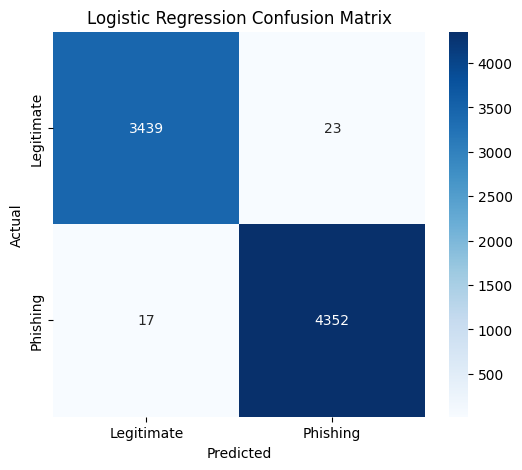

In [12]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Phishing"],
    yticklabels=["Legitimate","Phishing"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [13]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3462
           1       0.99      1.00      1.00      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.994892,0.994743,0.996109,0.995425
1,Naive Bayes,0.973694,0.996423,0.956283,0.975940
2,Random Forest,0.995403,0.997246,0.994507,0.995874
3,Neural Network,0.995658,0.995202,0.997024,0.996113


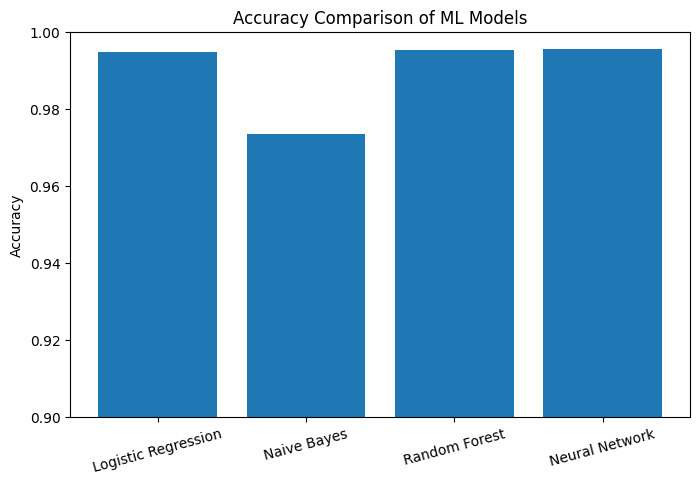

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Accuracy Comparison of ML Models")

plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

plt.xticks(rotation=15)

plt.show()

In [16]:
results_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.994892,0.994743,0.996109,0.995425
1,Naive Bayes,0.973694,0.996423,0.956283,0.975940
2,Random Forest,0.995403,0.997246,0.994507,0.995874
3,Neural Network,0.995658,0.995202,0.997024,0.996113


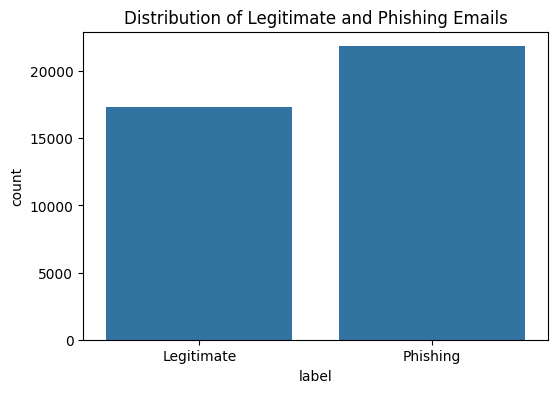

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["label"])

plt.title("Distribution of Legitimate and Phishing Emails")

plt.xticks([0,1],["Legitimate","Phishing"])

plt.show()

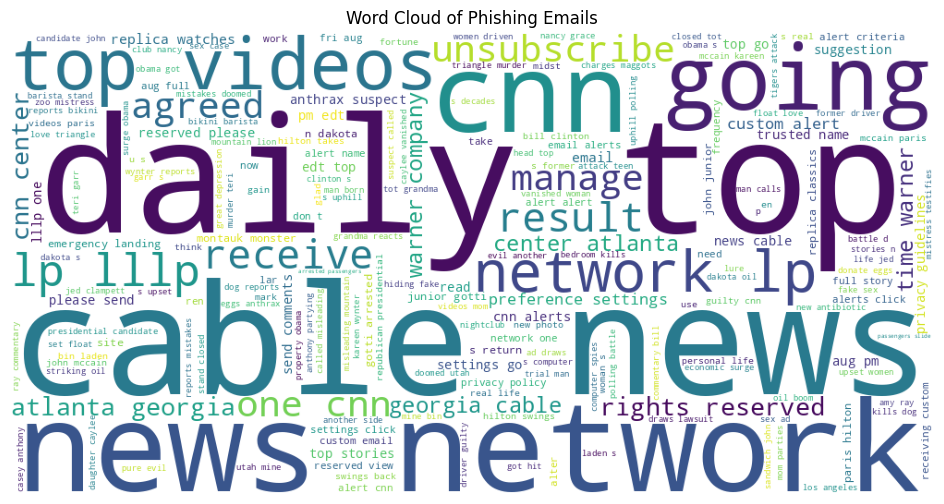

In [18]:
from wordcloud import WordCloud

phishing_text = " ".join(df[df["label"]==1]["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(phishing_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Phishing Emails")
plt.show()

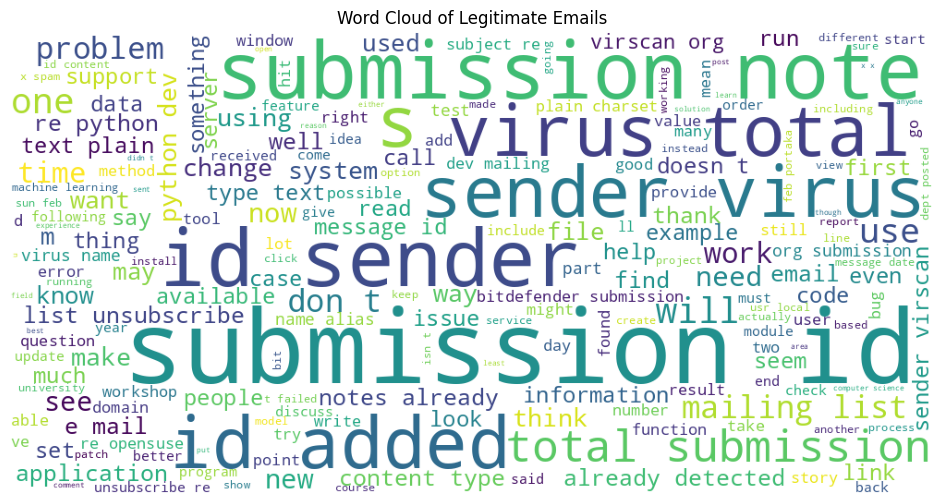

In [19]:
legitimate_text = " ".join(df[df["label"]==0]["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(legitimate_text)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Legitimate Emails")
plt.show()

In [20]:
import joblib

best_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

best_model.fit(X_train, y_train)

joblib.dump(best_model, "phishing_model.pkl")

joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [21]:
sample_email = """
Congratulations!

Your account has been suspended.

Click the link below immediately to verify your identity.

http://secure-login-bank.com
"""

sample_clean = clean_text(sample_email)

sample_vector = vectorizer.transform([sample_clean])

prediction = best_model.predict(sample_vector)

if prediction[0] == 1:
    print("🚨 Phishing Email Detected")
else:
    print("✅ Legitimate Email")

🚨 Phishing Email Detected


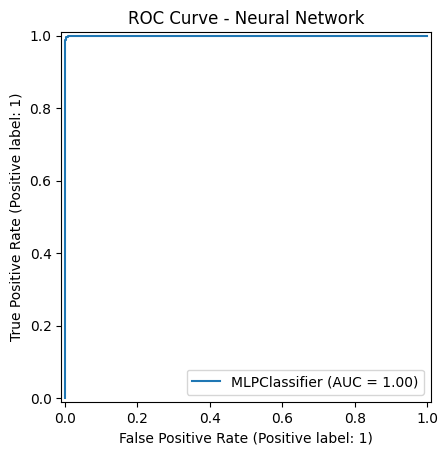

In [22]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("ROC Curve - Neural Network")
plt.show()

In [23]:
feature_names = vectorizer.get_feature_names_out()

print("Total Features:", len(feature_names))

print(feature_names[:50])

Total Features: 5000
['aa' 'aaai' 'aaas' 'aamas' 'aaron' 'ab' 'abc' 'ability' 'able' 'abrahams'
 'abs' 'absolute' 'absolutely' 'abstract' 'abstracts' 'absurd' 'abuse'
 'ac' 'academic' 'academy' 'accept' 'acceptable' 'acceptance' 'accepted'
 'accepts' 'access' 'accessible' 'accessories' 'according' 'account'
 'accounts' 'accuracy' 'accurate' 'achieve' 'achieved' 'acl' 'acm' 'acpi'
 'acpid' 'acquisition' 'act' 'acting' 'action' 'actions' 'active'
 'activities' 'activity' 'acts' 'actual' 'actually']
